In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -U bitsandbytes peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 52.3 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.18.0
    Uninstalling peft-0.18.0:
      Successfully uninstalled peft-0.18.0


In [5]:
# -*- coding: utf-8 -*-
"""internist7b_multitask_finetune.py

Adapted from your original script to fine-tune Internist-7B (internistai/base-7b-v0.2)
for multitask clinical prediction (mortality + LOS class) using the same architecture
(attention pooling + task heads), but with:
  1) A natural-language header as requested.
  2) Safer backbone kwargs handling (decoder-only models like Mistral/Internist don't accept token_type_ids).
  3) Optional QLoRA (4-bit) + LoRA adapters to make 7B fine-tuning feasible on a single GPU.

Notes:
- Internist.ai base-7b-v0.2 is Mistral-7B-v0.1 continued-pretraining (context length 4096). [1](https://huggingface.co/internistai/base-7b-v0.2)
- If you have enough VRAM for full fine-tuning, you can turn off QLoRA/LoRA.

"""

import os, inspect, ast
import numpy as np
import pandas as pd
from dataclasses import dataclass
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModel,
    TrainingArguments, Trainer,
    set_seed, EvalPrediction,
    EarlyStoppingCallback,
)

# Optional (recommended) for 7B fine-tuning
try:
    from transformers import BitsAndBytesConfig
    _HAS_BNB = True
except Exception:
    BitsAndBytesConfig = None
    _HAS_BNB = False

try:
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
    _HAS_PEFT = True
except Exception:
    LoraConfig = None
    get_peft_model = None
    prepare_model_for_kbit_training = None
    _HAS_PEFT = False

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize


# --------------------------------------------------
# Config
# --------------------------------------------------
@dataclass
class CFG:
    # data
    csv_path: str = "/content/drive/MyDrive/EHR/dx_encoded_feats.csv"

    # Internist-7B (Internist.ai) on HF
    model_name: str = "internistai/base-7b-v0.2"

    seed: int = 42

    # tokenization
    # Internist has 4096 context; increase carefully with VRAM.
    max_len: int = 1024
    max_dx: int = 60

    # split
    test_size: float = 0.15
    val_size: float = 0.15

    # task weights
    w_mort: float = 1.0
    w_los: float = 1.0

    # LOS bins: [0,3), [3,7), [7,14), [14,inf)
    los_bin_edges: tuple = (0.0, 3.0, 7.0, 14.0, float("inf"))
    los_bin_labels: tuple = ("0-3", "3-7", "7-14", "14+")

    # training
    epochs: int = 10
    lr: float = 2e-5
    train_bs: int = 2
    eval_bs: int = 4
    grad_accum: int = 8
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    lr_scheduler_type: str = "cosine"
    max_grad_norm: float = 1.0
    early_stop_patience: int = 4

    # mortality imbalance
    use_focal: bool = True
    focal_gamma: float = 2.0
    focal_alpha: float = 0.25

    # structured features
    use_structured_feats: bool = True  # age + n_dx

    # optional tokenizer expansion for code-like tokens
    add_code_tokens_to_tokenizer: bool = False
    max_added_tokens: int = 3000

    # mortality threshold policy (for final F1)
    threshold_mode: str = "f1"  # "f1" | "recall" | "precision"
    target_recall: float = 0.70
    target_precision: float = 0.50

    # bootstrap CI
    n_boot: int = 2000
    ci_alpha: float = 0.05

    # save
    save_dir: str = "internist7b_multitask_saved"

    # ---- New: memory-friendly 7B fine-tuning options ----
    # If True, load the backbone in 4-bit and train only LoRA adapters.
    use_qlora: bool = True

    # LoRA hyperparameters
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05

    # Typical Mistral target modules. If your model uses different names, adjust.
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj",
                                  "gate_proj", "up_proj", "down_proj")


cfg = CFG()
set_seed(cfg.seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Mixed precision choice
use_bf16, use_fp16 = False, False
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    use_bf16 = (major >= 8)  # A100+
    use_fp16 = not use_bf16  # T4/V100
print("bf16:", use_bf16, "fp16:", use_fp16)


# --------------------------------------------------
# Version-proof TrainingArguments builder
# --------------------------------------------------
def make_training_args(**kwargs):
    sig = inspect.signature(TrainingArguments.__init__)
    params = sig.parameters
    if "eval_strategy" in params and "evaluation_strategy" in kwargs:
        kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")
    if "evaluation_strategy" in params and "eval_strategy" in kwargs:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    filtered = {k: v for k, v in kwargs.items() if k in params}
    return TrainingArguments(**filtered)


# --------------------------------------------------
# Bootstrap CI utilities
# --------------------------------------------------
def bootstrap_ci(y_true, x, metric_fn, n_boot=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    x = np.asarray(x)
    n = len(y_true)
    point = metric_fn(y_true, x)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        xs = x[idx]
        try:
            v = metric_fn(yt, xs)
            if np.isfinite(v):
                stats.append(v)
        except Exception:
            pass
    stats = np.array(stats)
    lo = np.quantile(stats, alpha / 2)
    hi = np.quantile(stats, 1 - alpha / 2)
    return float(point), float(lo), float(hi)


def pct3(t):
    return (100.0 * t[0], 100.0 * t[1], 100.0 * t[2])


def fmt_ci(p, lo, hi, d=2):
    return f"{p:.{d}f} ({lo:.{d}f}, {hi:.{d}f})"


# --------------------------------------------------
# Dataset-specific helpers
# --------------------------------------------------
def safe_get(row, col, default="NA"):
    v = row.get(col, default)
    if pd.isna(v):
        return default
    return v


def parse_list_str(x):
    """Parses stringified Python lists like "['CIR019']" safely."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    if not s:
        return []
    try:
        out = ast.literal_eval(s)
        return out if isinstance(out, list) else []
    except Exception:
        return []


def los_to_class(los_days, edges):
    for k in range(len(edges) - 1):
        if edges[k] <= los_days < edges[k + 1]:
            return k
    return len(edges) - 2


# ---- UPDATED TEXT BUILDER (requested header) ----
def build_admission_text(g: pd.DataFrame, max_dx: int = 60) -> str:
    """Builds an admission-level prompt string.

    Uses:
    - Natural-language demographic/admission header (as requested).
    - Diagnoses in order using dx_norm (fallback icd10_full) + up to 2 CCSR codes.

    The resulting 'text' is fed into the tokenizer.
    """
    g = g.sort_values("seq_num")
    r = g.iloc[0]

    header = (
        f"A {safe_get(r,'gender')} patient, {safe_get(r,'age_at_admit')} years old, "
        f"was admitted ({safe_get(r,'admission_type')}) via {safe_get(r,'admission_location')}. "
        f"Insurance: {safe_get(r,'insurance')}. Race: {safe_get(r,'race')}. "
        f"Diagnoses in order:"
    )

    lines = []
    for i, (_, row) in enumerate(g.head(max_dx).iterrows(), start=1):
        dx = str(row.get("dx_norm", "")).strip()
        if (not dx) or dx.lower() == "nan" or dx == "NoDx":
            dx = str(row.get("icd10_full", "")).strip()
        if (not dx) or dx.lower() == "nan":
            continue

        ccsr_codes = parse_list_str(row.get("ccsr_list_sorted", ""))
        ccsr_codes = [str(c).strip() for c in ccsr_codes if str(c).strip()]
        ccsr_txt = f" (CCSR: {', '.join(ccsr_codes[:2])})" if ccsr_codes else ""
        lines.append(f"{i}. {dx}{ccsr_txt}")

    if not lines:
        lines = ["1. NA"]

    return header + "\n" + "\n".join(lines)


def make_admission_level_df(df: pd.DataFrame, max_dx: int, edges) -> pd.DataFrame:
    rows = []
    for (subject_id, hadm_id), g in df.groupby(["subject_id", "hadm_id"], sort=False):
        g0 = g.iloc[0]
        y_mort = int(g0["hospital_expire_flag"])
        y_los = float(g0["los_days"])
        y_los_cls = int(los_to_class(y_los, edges))

        # structured feats
        age_raw = g0.get("age_at_admit", np.nan)
        try:
            age = float(age_raw)
        except Exception:
            age = np.nan
        if np.isnan(age):
            age = 0.0
        n_dx = int(len(g))

        rows.append({
            "subject_id": int(subject_id),
            "hadm_id": int(hadm_id),
            "text": build_admission_text(g, max_dx=max_dx),
            "y_mort": y_mort,
            "y_los": y_los,
            "y_los_cls": y_los_cls,
            "race": str(g0.get("race", "UNKNOWN")),
            "age": age,
            "n_dx": n_dx,
        })
    return pd.DataFrame(rows)


# --------------------------------------------------
# Subject-wise stratified split by race
# --------------------------------------------------
def split_subject_wise_stratified_by_race(df_adm: pd.DataFrame, seed: int, test_size: float, val_size: float):
    subj = (
        df_adm.groupby("subject_id")["race"]
        .agg(lambda x: x.value_counts().index[0])
        .reset_index()
        .rename(columns={"race": "race_subj"})
    )

    subjects = subj["subject_id"].values
    y_race = subj["race_subj"].values

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(sss1.split(subjects, y_race))

    trainval_subjects = set(subjects[trainval_idx])
    test_subjects = set(subjects[test_idx])

    df_test = df_adm[df_adm["subject_id"].isin(test_subjects)].reset_index(drop=True)

    subj_trval = subj[subj["subject_id"].isin(trainval_subjects)].reset_index(drop=True)
    subjects_trval = subj_trval["subject_id"].values
    y_race_trval = subj_trval["race_subj"].values

    val_size_inside = val_size / (1.0 - test_size)
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size_inside, random_state=seed + 1)
    tr_idx, val_idx = next(sss2.split(subjects_trval, y_race_trval))

    train_subjects = set(subjects_trval[tr_idx])
    val_subjects = set(subjects_trval[val_idx])

    df_train = df_adm[df_adm["subject_id"].isin(train_subjects)].reset_index(drop=True)
    df_val = df_adm[df_adm["subject_id"].isin(val_subjects)].reset_index(drop=True)
    return df_train, df_val, df_test


# --------------------------------------------------
# Tokenizer + datasets
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)

# Mistral-derived tokenizers sometimes have no pad_token; set it to eos.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token else tokenizer.unk_token


def tokenize_batch(examples):
    return tokenizer(examples["text"], truncation=True, padding=False, max_length=cfg.max_len)


class DataCollatorMultiTask:
    def __init__(self, tokenizer, use_structured_feats=True):
        self.tokenizer = tokenizer
        self.use_structured_feats = use_structured_feats

    def __call__(self, features):
        y_mort = torch.tensor([f["y_mort"] for f in features], dtype=torch.float32)
        y_los_cls = torch.tensor([f["y_los_cls"] for f in features], dtype=torch.long)

        batch = self.tokenizer.pad(
            [{"input_ids": f["input_ids"], "attention_mask": f["attention_mask"]} for f in features],
            padding=True,
            return_tensors="pt",
        )

        batch["y_mort"] = y_mort
        batch["y_los_cls"] = y_los_cls

        if self.use_structured_feats:
            feats = torch.tensor(
                [[float(f.get("age", 0.0)), float(f.get("n_dx", 0.0))] for f in features],
                dtype=torch.float32,
            )
            batch["feats"] = feats

        return batch


# --------------------------------------------------
# Loss (mortality focal optional)
# --------------------------------------------------
def focal_loss_with_logits(logits, targets, alpha=0.25, gamma=2.0, reduction="mean", pos_weight=None):
    device_ = logits.device
    targets = targets.to(device=device_, dtype=logits.dtype)
    if pos_weight is not None:
        pos_weight = pos_weight.to(device=device_, dtype=logits.dtype)

    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none", pos_weight=pos_weight)
    p = torch.sigmoid(logits)
    pt = torch.where(targets == 1, p, 1 - p)
    a_t = torch.where(targets == 1, alpha, 1 - alpha)
    loss = a_t * (1 - pt) ** gamma * bce
    return loss.mean() if reduction == "mean" else loss.sum()


# --------------------------------------------------
# Model (decoder-only safe kwargs) + optional QLoRA
# --------------------------------------------------
class AttnPool(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.score = nn.Linear(hidden_size, 1)

    def forward(self, x, mask):
        scores = self.score(x).squeeze(-1).float()
        scores = scores.masked_fill(mask == 0, -1e9)
        w = torch.softmax(scores, dim=1).to(dtype=x.dtype).unsqueeze(-1)
        return (x * w).sum(dim=1)


class MultiTaskLLM(nn.Module):
    def __init__(
        self,
        backbone_name: str,
        num_los_classes: int,
        dropout: float = 0.1,
        pos_weight=None,
        use_focal=False,
        focal_alpha=0.25,
        focal_gamma=2.0,
        use_structured_feats=True,
        use_qlora: bool = False,
        lora_cfg: dict | None = None,
    ):
        super().__init__()

        self.use_qlora = use_qlora

        quant_cfg = None
        if use_qlora:
            if not _HAS_BNB:
                raise ImportError("BitsAndBytesConfig not available. Install bitsandbytes.")
            quant_cfg = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
            )

        self.backbone = AutoModel.from_pretrained(
            backbone_name,
            quantization_config=quant_cfg,
            device_map="auto" if use_qlora else None,
        )

        # If QLoRA, prepare for k-bit training + add LoRA adapters
        if use_qlora:
            if not _HAS_PEFT:
                raise ImportError("peft not available. Install peft.")
            self.backbone = prepare_model_for_kbit_training(self.backbone)
            lc = lora_cfg or {}
            lora = LoraConfig(
                r=lc.get("r", 16),
                lora_alpha=lc.get("alpha", 32),
                lora_dropout=lc.get("dropout", 0.05),
                bias="none",
                task_type="FEATURE_EXTRACTION",
                target_modules=lc.get("target_modules", ["q_proj", "k_proj", "v_proj", "o_proj"]),
            )
            self.backbone = get_peft_model(self.backbone, lora)

        h = self.backbone.config.hidden_size
        self.pool = AttnPool(h)
        self.drop = nn.Dropout(dropout)
        self.use_structured_feats = use_structured_feats

        if self.use_structured_feats:
            self.feat_mlp = nn.Sequential(
                nn.Linear(2, 16),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            out_in = h + 16
        else:
            out_in = h

        self.mort_head = nn.Linear(out_in, 1)
        self.los_cls_head = nn.Linear(out_in, num_los_classes)

        if pos_weight is None:
            self.pos_weight = None
        else:
            self.register_buffer("pos_weight", pos_weight)

        self.use_focal = use_focal
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma

        # Cache backbone forward signature for safe kwargs filtering
        try:
            self._bb_sig = inspect.signature(self.backbone.forward)
        except Exception:
            self._bb_sig = None

    def _backbone_forward(self, input_ids, attention_mask, **kwargs):
        # Filter out kwargs that decoder-only models don't support (e.g., token_type_ids)
        if self._bb_sig is None:
            clean = {k: v for k, v in kwargs.items() if v is not None}
            return self.backbone(input_ids=input_ids, attention_mask=attention_mask, **clean)

        clean = {}
        for k, v in kwargs.items():
            if v is None:
                continue
            if k in self._bb_sig.parameters:
                clean[k] = v
        return self.backbone(input_ids=input_ids, attention_mask=attention_mask, **clean)

    def forward(
        self,
        input_ids,
        attention_mask,
        feats=None,
        y_mort=None,
        y_los_cls=None,
        w_mort=1.0,
        w_los=1.0,
        **kwargs,
    ):
        out = self._backbone_forward(input_ids=input_ids, attention_mask=attention_mask, **kwargs)
        pooled = self.drop(self.pool(out.last_hidden_state, attention_mask))

        if self.use_structured_feats:
            if feats is None:
                feats = torch.zeros((pooled.size(0), 2), device=pooled.device, dtype=pooled.dtype)
            fused = torch.cat([pooled, self.feat_mlp(feats)], dim=1)
        else:
            fused = pooled

        mort_logits = self.mort_head(fused).squeeze(-1)
        los_logits = self.los_cls_head(fused)

        loss = None
        if (y_mort is not None) or (y_los_cls is not None):
            loss = 0.0
            if y_mort is not None:
                if self.use_focal:
                    mort_loss = focal_loss_with_logits(
                        mort_logits,
                        y_mort.float(),
                        alpha=self.focal_alpha,
                        gamma=self.focal_gamma,
                        pos_weight=self.pos_weight,
                    )
                else:
                    mort_loss = F.binary_cross_entropy_with_logits(
                        mort_logits, y_mort.float(), pos_weight=self.pos_weight
                    )
                loss = loss + w_mort * mort_loss

            if y_los_cls is not None:
                loss = loss + w_los * F.cross_entropy(los_logits, y_los_cls)

        return {"loss": loss, "mort_logits": mort_logits, "los_logits": los_logits}


# --------------------------------------------------
# Custom Trainer
# --------------------------------------------------
class MultiTaskTrainer(Trainer):
    def __init__(self, *args, w_mort=1.0, w_los=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.w_mort = w_mort
        self.w_los = w_los

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        out = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            feats=inputs.get("feats", None),
            y_mort=inputs["y_mort"],
            y_los_cls=inputs["y_los_cls"],
            w_mort=self.w_mort,
            w_los=self.w_los,
        )
        loss = out["loss"]
        return (loss, out) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        with torch.no_grad():
            outputs = model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                feats=inputs.get("feats", None),
                y_mort=inputs["y_mort"],
                y_los_cls=inputs["y_los_cls"],
                w_mort=self.w_mort,
                w_los=self.w_los,
            )
        loss = outputs["loss"].detach()
        if prediction_loss_only:
            return (loss, None, None)
        preds = (outputs["mort_logits"].detach(), outputs["los_logits"].detach())
        labels = (inputs["y_mort"].detach(), inputs["y_los_cls"].detach())
        return (loss, preds, labels)


# --------------------------------------------------
# Multiclass AUROC helper (OvR macro)
# --------------------------------------------------
def multiclass_auc_ovr_macro(y_true_cls, prob_2d):
    y_true_cls = np.asarray(y_true_cls).astype(int)
    prob_2d = np.asarray(prob_2d)
    K = prob_2d.shape[1]
    Y = label_binarize(y_true_cls, classes=list(range(K)))
    return roc_auc_score(Y, prob_2d, average="macro", multi_class="ovr")


# --------------------------------------------------
# compute_metrics for Trainer
# --------------------------------------------------
def compute_metrics(p: EvalPrediction):
    mort_logits = p.predictions[0]
    los_logits = p.predictions[1]
    y_mort = p.label_ids[0]
    y_los_cls = p.label_ids[1]

    mort_prob = 1.0 / (1.0 + np.exp(-mort_logits))
    mort_auc = roc_auc_score(y_mort, mort_prob) if len(np.unique(y_mort)) > 1 else np.nan
    mort_ap = average_precision_score(y_mort, mort_prob) if len(np.unique(y_mort)) > 1 else np.nan

    mort_pred = (mort_prob >= 0.5).astype(int)
    mort_f1 = f1_score(y_mort, mort_pred, zero_division=0)

    expz = np.exp(los_logits - los_logits.max(axis=1, keepdims=True))
    los_prob = expz / expz.sum(axis=1, keepdims=True)
    los_pred = np.argmax(los_prob, axis=1)

    los_macro_f1 = f1_score(y_los_cls, los_pred, average="macro", zero_division=0)
    try:
        los_auc = multiclass_auc_ovr_macro(y_los_cls, los_prob)
    except Exception:
        los_auc = np.nan

    return {
        "mort_auc": mort_auc,
        "mort_ap": mort_ap,
        "mort_f1@0.5": mort_f1,
        "los_macro_f1": los_macro_f1,
        "los_auc": los_auc,
    }


# --------------------------------------------------
# Mortality threshold tuning
# --------------------------------------------------
def find_best_threshold_by_f1(y_true, prob, t_min=0.001, t_max=0.99, steps=1200):
    ts = np.linspace(t_min, t_max, steps)
    f1s = [f1_score(y_true, (prob >= t).astype(int), zero_division=0) for t in ts]
    i = int(np.argmax(f1s))
    return float(ts[i]), float(f1s[i])


def threshold_for_target_recall(y_true, prob, target_recall=0.70, grid=2000):
    ts = np.linspace(0.999, 0.001, grid)
    for t in ts:
        pred = (prob >= t).astype(int)
        r = recall_score(y_true, pred, zero_division=0)
        if r >= target_recall:
            p = precision_score(y_true, pred, zero_division=0)
            f1v = f1_score(y_true, pred, zero_division=0)
            return float(t), float(p), float(r), float(f1v)
    return None


def threshold_for_target_precision(y_true, prob, target_precision=0.50, grid=2000):
    ts = np.linspace(0.001, 0.999, grid)
    for t in ts:
        pred = (prob >= t).astype(int)
        p = precision_score(y_true, pred, zero_division=0)
        if p >= target_precision:
            r = recall_score(y_true, pred, zero_division=0)
            f1v = f1_score(y_true, pred, zero_division=0)
            return float(t), float(p), float(r), float(f1v)
    return None


@torch.no_grad()
def predict_mort_probs(model, tokenizer, df_part, max_len, batch_size=16, use_structured_feats=True):
    model.eval()
    logits_all = []
    for i in range(0, len(df_part), batch_size):
        bdf = df_part.iloc[i:i + batch_size]
        enc = tokenizer(
            bdf["text"].tolist(),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        feats = None
        if use_structured_feats:
            feats = torch.tensor(
                np.stack([bdf["age"].values, bdf["n_dx"].values], axis=1),
                dtype=torch.float32,
                device=device,
            )

        out = model(**enc, feats=feats)
        logits_all.append(out["mort_logits"].detach().cpu().numpy())

    logits = np.concatenate(logits_all)
    prob = 1.0 / (1.0 + np.exp(-logits))
    return prob, logits


@torch.no_grad()
def predict_los_probs(model, tokenizer, df_part, max_len, batch_size=16, use_structured_feats=True):
    model.eval()
    logits_all = []
    for i in range(0, len(df_part), batch_size):
        bdf = df_part.iloc[i:i + batch_size]
        enc = tokenizer(
            bdf["text"].tolist(),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        feats = None
        if use_structured_feats:
            feats = torch.tensor(
                np.stack([bdf["age"].values, bdf["n_dx"].values], axis=1),
                dtype=torch.float32,
                device=device,
            )

        out = model(**enc, feats=feats)
        logits_all.append(out["los_logits"].detach().cpu().numpy())

    los_logits = np.concatenate(logits_all)
    expz = np.exp(los_logits - los_logits.max(axis=1, keepdims=True))
    los_prob = expz / expz.sum(axis=1, keepdims=True)
    los_pred = np.argmax(los_prob, axis=1)
    return los_prob, los_pred


# --------------------------------------------------
# Main
# --------------------------------------------------
def main():
    edges = cfg.los_bin_edges
    K = len(edges) - 1
    print("LOS bins:", edges, "K=", K, "labels:", cfg.los_bin_labels)

    df = pd.read_csv(cfg.csv_path)

    # admission-level
    df_adm = make_admission_level_df(df, max_dx=cfg.max_dx, edges=edges)
    print("admissions:", len(df_adm))
    print("mortality rate:", df_adm["y_mort"].mean())
    print("LOS class counts:", df_adm["y_los_cls"].value_counts().sort_index().to_dict())

    # split
    df_train, df_val, df_test = split_subject_wise_stratified_by_race(
        df_adm, seed=cfg.seed, test_size=cfg.test_size, val_size=cfg.val_size
    )
    print("train/val/test:", len(df_train), len(df_val), len(df_test))

    # optional tokenizer expansion
    if cfg.add_code_tokens_to_tokenizer:
        all_tok = []
        for t in df_train["text"].astype(str).tolist():
            for w in t.split():
                if w.startswith("DX_") or w.startswith("CCSR_"):
                    all_tok.append(w)
        vocab = [w for w, c in Counter(all_tok).most_common(cfg.max_added_tokens)]
        added = tokenizer.add_tokens(vocab, special_tokens=False)
        print("Added tokens:", added)

    feat_cols = ["age", "n_dx"] if cfg.use_structured_feats else []
    base_cols = ["text", "y_mort", "y_los_cls"]

    train_ds = Dataset.from_pandas(df_train[base_cols + feat_cols])
    val_ds   = Dataset.from_pandas(df_val[base_cols + feat_cols])
    test_ds  = Dataset.from_pandas(df_test[base_cols + feat_cols])

    train_ds = train_ds.map(tokenize_batch, batched=True)
    val_ds   = val_ds.map(tokenize_batch, batched=True)
    test_ds  = test_ds.map(tokenize_batch, batched=True)

    cols = ["input_ids", "attention_mask", "y_mort", "y_los_cls"] + feat_cols
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    collator = DataCollatorMultiTask(tokenizer, use_structured_feats=cfg.use_structured_feats)

    # pos_weight for mortality
    pos = df_train["y_mort"].sum()
    neg = len(df_train) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)
    print("pos_weight:", pos_weight.item())

    lora_cfg = {
        "r": cfg.lora_r,
        "alpha": cfg.lora_alpha,
        "dropout": cfg.lora_dropout,
        "target_modules": list(cfg.lora_target_modules),
    }

    model = MultiTaskLLM(
        cfg.model_name,
        num_los_classes=K,
        pos_weight=pos_weight,
        use_focal=cfg.use_focal,
        focal_alpha=cfg.focal_alpha,
        focal_gamma=cfg.focal_gamma,
        use_structured_feats=cfg.use_structured_feats,
        use_qlora=cfg.use_qlora,
        lora_cfg=lora_cfg,
    )

    # If not QLoRA, move entire model to device
    if not cfg.use_qlora:
        model = model.to(device)

    if cfg.add_code_tokens_to_tokenizer:
        try:
            model.backbone.resize_token_embeddings(len(tokenizer))
        except Exception as e:
            print("Warning: could not resize embeddings:", e)

    args = make_training_args(
        output_dir="internist7b_multitask_out",
        learning_rate=cfg.lr,
        num_train_epochs=cfg.epochs,
        per_device_train_batch_size=cfg.train_bs,
        per_device_eval_batch_size=cfg.eval_bs,
        gradient_accumulation_steps=cfg.grad_accum,
        eval_strategy="epoch",
        save_strategy="epoch",
        weight_decay=cfg.weight_decay,
        warmup_ratio=cfg.warmup_ratio,
        lr_scheduler_type=cfg.lr_scheduler_type,
        max_grad_norm=cfg.max_grad_norm,
        fp16=use_fp16,
        bf16=use_bf16,
        load_best_model_at_end=True,
        metric_for_best_model="mort_ap",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        save_total_limit=2,
    )

    trainer = MultiTaskTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collator,
        compute_metrics=compute_metrics,
        w_mort=cfg.w_mort,
        w_los=cfg.w_los,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg.early_stop_patience)],
    )

    print("\n--- Training ---")
    trainer.train()

    # Threshold tuning on VAL (mortality)
    print("\n--- Threshold tuning on VAL (mortality) ---")
    y_val = df_val["y_mort"].values.astype(int)
    mort_prob_val, _ = predict_mort_probs(model, tokenizer, df_val, cfg.max_len, cfg.eval_bs, cfg.use_structured_feats)

    if cfg.threshold_mode.lower() == "f1":
        t_star, f1v = find_best_threshold_by_f1(y_val, mort_prob_val)
        print(f"Best VAL threshold (F1): {t_star:.4f} F1={f1v:.4f}")
    elif cfg.threshold_mode.lower() == "recall":
        res = threshold_for_target_recall(y_val, mort_prob_val, target_recall=cfg.target_recall)
        t_star = res[0] if res else find_best_threshold_by_f1(y_val, mort_prob_val)[0]
        print("VAL threshold (recall policy):", t_star)
    elif cfg.threshold_mode.lower() == "precision":
        res = threshold_for_target_precision(y_val, mort_prob_val, target_precision=cfg.target_precision)
        t_star = res[0] if res else find_best_threshold_by_f1(y_val, mort_prob_val)[0]
        print("VAL threshold (precision policy):", t_star)
    else:
        raise ValueError("threshold_mode must be f1 | recall | precision")

    # TEST: compute CIs
    print("\n--- TEST: F1 & AUROC with 95% bootstrap CI ---")
    y_test_m = df_test["y_mort"].values.astype(int)
    y_test_l = df_test["y_los_cls"].values.astype(int)

    mort_prob_test, _ = predict_mort_probs(model, tokenizer, df_test, cfg.max_len, cfg.eval_bs, cfg.use_structured_feats)
    mort_pred_test = (mort_prob_test >= t_star).astype(int)

    print("Mortality CM:\n", confusion_matrix(y_test_m, mort_pred_test))

    los_prob_test, los_pred_test = predict_los_probs(model, tokenizer, df_test, cfg.max_len, cfg.eval_bs, cfg.use_structured_feats)

    mort_f1_ci = bootstrap_ci(
        y_test_m,
        mort_pred_test,
        metric_fn=lambda yt, yp: f1_score(yt, yp, zero_division=0),
        n_boot=cfg.n_boot,
        alpha=cfg.ci_alpha,
        seed=cfg.seed,
    )

    mort_auc_ci = bootstrap_ci(
        y_test_m,
        mort_prob_test,
        metric_fn=lambda yt, ps: roc_auc_score(yt, ps) if len(np.unique(yt)) > 1 else np.nan,
        n_boot=cfg.n_boot,
        alpha=cfg.ci_alpha,
        seed=cfg.seed,
    )

    los_f1_ci = bootstrap_ci(
        y_test_l,
        los_pred_test,
        metric_fn=lambda yt, yp: f1_score(yt, yp, average="macro", zero_division=0),
        n_boot=cfg.n_boot,
        alpha=cfg.ci_alpha,
        seed=cfg.seed,
    )

    los_auc_ci = bootstrap_ci(
        y_test_l,
        los_prob_test,
        metric_fn=lambda yt, prob: multiclass_auc_ovr_macro(yt, prob),
        n_boot=cfg.n_boot,
        alpha=cfg.ci_alpha,
        seed=cfg.seed,
    )

    mf1p, mf1l, mf1h = pct3(mort_f1_ci)
    maucp, maucl, mauch = pct3(mort_auc_ci)
    lf1p, lf1l, lf1h = pct3(los_f1_ci)
    lau_cp, lau_cl, lau_ch = pct3(los_auc_ci)

    print("\n=== Performance Values (%, 95% CI) ===")
    print("Length-of-Stay Prediction (multiclass bins):")
    print(" Macro F1 (%):", fmt_ci(lf1p, lf1l, lf1h))
    print(" AUROC (%): ", fmt_ci(lau_cp, lau_cl, lau_ch))

    print("\nMortality Prediction:")
    print(" F1 (%): ", fmt_ci(mf1p, mf1l, mf1h))
    print(" AUROC (%): ", fmt_ci(maucp, maucl, mauch))

    # Save
    os.makedirs(cfg.save_dir, exist_ok=True)
    trainer.save_model(cfg.save_dir)
    tokenizer.save_pretrained(cfg.save_dir)
    print("\nSaved to:", cfg.save_dir)


if __name__ == "__main__":
    main()

device: cuda
bf16: True fp16: False


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

...


--- Training ---


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Mort Auc,Mort Ap,Mort F1@0.5,Los Macro F1,Los Auc
1,1.144700,1.160504,0.939448,0.271346,0.000000,0.350975,0.813090
2,0.940500,0.972207,0.954454,0.375126,0.424242,0.426998,0.827278
3,0.879600,0.887365,0.969678,0.466659,0.477273,0.434825,0.839401
4,0.839700,0.855514,0.974527,0.539975,0.546667,0.526375,0.840224
5,0.720900,0.955699,0.974654,0.552440,0.537037,0.488722,0.839372
6,0.568800,1.088719,0.977433,0.573116,0.531915,0.521964,0.838637
7,0.292000,1.686371,0.968738,0.574424,0.500000,0.523620,0.832834
8,0.147900,2.346798,0.957633,0.582940,0.500000,0.521638,0.823936
9,0.031100,3.062192,0.941742,0.573576,0.394366,0.517555,0.819346
10,0.009500,3.178444,0.941013,0.567159,0.438356,0.522929,0.817141


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


--- Threshold tuning on VAL (mortality) ---
Best VAL threshold (F1): 0.4786 F1=0.6142

--- TEST: F1 & AUROC with 95% bootstrap CI ---
Mortality CM:
 [[1718   35]
 [  26   23]]

=== Performance Values (%, 95% CI) ===
Length-of-Stay Prediction (multiclass bins):
 Macro F1 (%): 51.80 (48.68, 54.46)
 AUROC (%):  81.53 (79.92, 82.98)

Mortality Prediction:
 F1 (%):  42.99 (30.43, 54.40)
 AUROC (%):  90.63 (85.90, 94.60)

Saved to: internist7b_multitask_saved


Figure saved to: /content/drive/MyDrive/EHR/mortality_confusion_matrix.png


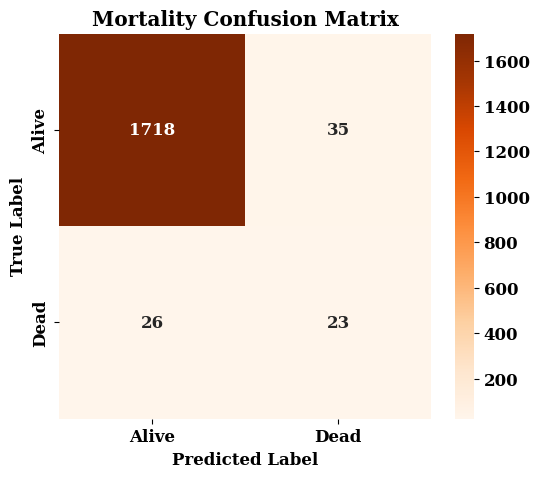

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set global font properties
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

# Given confusion matrix
cm = np.array([
    [1718, 35],
    [26, 23]
])

# Labels for the heatmap
labels = ['Alive', 'Dead']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Mortality Confusion Matrix', fontweight='bold')

# Save the figure to Google Drive
save_path = '/content/drive/MyDrive/EHR/mortality_confusion_matrix.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")

plt.show()